# Big Ideas in Computing and Information --- Neighborhood Project
Created by **Mason Pavelik**, **Michael Tichy**, and **Luke Douglas**

## Introduction

## Code

### Mason - Condemned Properties

neighborhood
Duquesne Heights              1
Strip District                1
Friendship                    1
Allegheny West                1
Central Oakland               1
                           ... 
Knoxville                   180
Lincoln-Lemington-Belmar    183
Homewood North              183
Perry South                 185
Hazelwood                   201
Name: count, Length: 85, dtype: int64
neighborhood
Duquesne Heights             1
Strip District               1
Friendship                   1
Allegheny West               1
Central Oakland              1
Chateau                      1
Central Business District    1
South Shore                  1
Banksville                   2
Swisshelm Park               2
North Oakland                2
Arlington Heights            2
Summer Hill                  3
Glen Hazel                   3
Point Breeze                 4
Name: count, dtype: int64


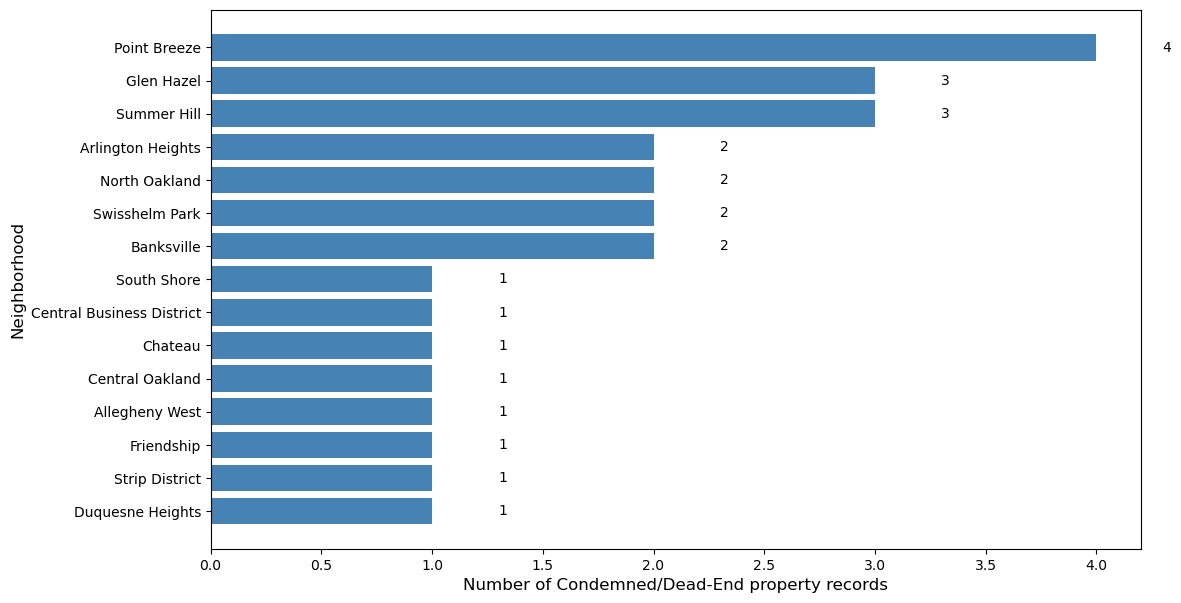

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('condemnedanddead-endproperties.csv')
df.head()

#This counts how many rows, property records, each neighborhood has
#Then sorts from lowest to highest because fewest condemned houses is the best neighborhood
neighborhood_counts = df['neighborhood'].value_counts().sort_values(ascending=True)
print(neighborhood_counts)

#This takes the first 15 neighborhoods from the sorted list
best_neighborhoods = neighborhood_counts.head(15)
print(best_neighborhoods)

plt.figure(figsize=(12,7))
plt.barh(best_neighborhoods.index, best_neighborhoods.values, color = 'steelblue')
plt.xlabel('Number of Condemned/Dead-End property records', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)

for i, value in enumerate(best_neighborhoods.values):
    plt.text(value + 0.3, i, str(value), va='center', fontsize = 10)

plt.show()

We can see that there are 8 neighborhoods tied at only 1 condemned or dead-end property. Let's narrow it down by investigating the inspection scores for each of these.

In [6]:
#Get the 8 tied neighborhoods
tied = neighborhood_counts[neighborhood_counts == 1].index

#Filter the original dataframe to only the top 8
tied_df = df[df['neighborhood'].isin(tied)]

summary = tied_df[['neighborhood', 'latest_inspection_result', 'latest_inspection_score', 'inspection_status']]
print(summary.to_string(index=False))

             neighborhood latest_inspection_result  latest_inspection_score inspection_status
              South Shore                     Fail                      3.0            Active
                  Chateau                     Fail                      1.0            Active
Central Business District                     Fail                      1.0            Active
         Duquesne Heights                     Pass                      0.0            Active
           Strip District                     Fail                      1.0            Active
               Friendship                     Fail                      1.0            Active
           Allegheny West                     Fail                      2.0            Active
          Central Oakland                     Pass                      0.0            Active


Now, let's visualize these results.

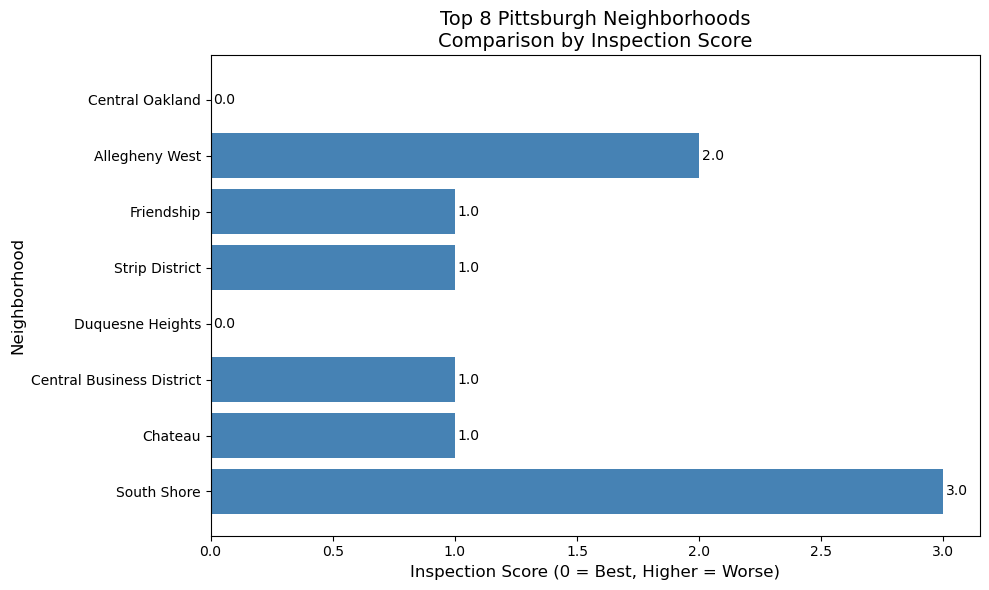

In [8]:
# Set up the graph using inspection score (0 = best, higher = worse)
plt.figure(figsize=(10, 6))

plt.barh(summary['neighborhood'], summary['latest_inspection_score'], color='steelblue')

plt.xlabel('Inspection Score (0 = Best, Higher = Worse)', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.title('Top 8 Pittsburgh Neighborhoods\nComparison by Inspection Score', fontsize=14)

# Add the score number at the end of each bar
for i, value in enumerate(summary['latest_inspection_score']):
    plt.text(value + 0.01, i, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

We can see that the properties in **Central Oakland** and **Duquesne Heights** have the lowest (better) scores, so they are the best neighborhoods by this metric.

### Michael - Transit Stops

In [10]:
# import dataset
import pandas as pd
stops = pd.read_csv('transitstops.csv')

Print out the amount of bus and rail stops in each neighborhood:

In [11]:
stopsperhoodRail = stops[stops['mode'] == 'RAIL']['hood'].value_counts()
print(stopsperhoodRail.head())
print()
stopsperhoodBus = stops[stops['mode'] == 'BUS']['hood'].value_counts()
print(stopsperhoodBus.head())

hood
Beechview                    12
Central Business District     8
Mount Washington              4
Bon Air                       2
Beltzhoover                   2
Name: count, dtype: int64

hood
Bloomfield                  93
Mount Washington            91
Lincoln-Lemington-Belmar    80
Shadyside                   76
Squirrel Hill North         76
Name: count, dtype: int64


Now, we use math to score each neighborhood in a more meaningful way.

                         hood  stop_score
15  Central Business District       180.0
51           Mount Washington       118.7
8                  Bloomfield        98.5
66                  Shadyside        87.1
74        Squirrel Hill North        86.9
12                  Brookline        85.0
45   Lincoln-Lemington-Belmar        84.7
75        Squirrel Hill South        80.1
35                 Greenfield        79.2
27               East Liberty        72.3
                           hood  stop_score
57                      Oakwood         9.5
30                    Fairywood         9.0
3   Arlington-Arlington Heights         8.0
36                         Hays         7.0
19               Chartiers City         6.0
25                East Carnegie         4.0
53                New Homestead         4.0
80               Swisshelm Park         3.3
76                    St. Clair         3.0
65                    Ridgemont         2.0


<Axes: title={'center': 'Stop Score by Neighborhood'}, ylabel='hood'>

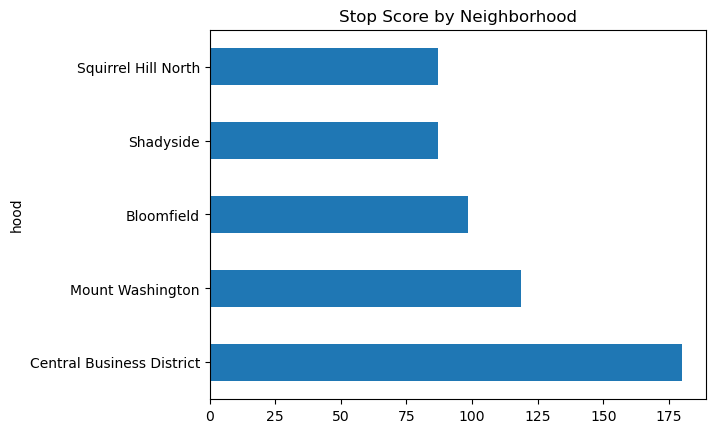

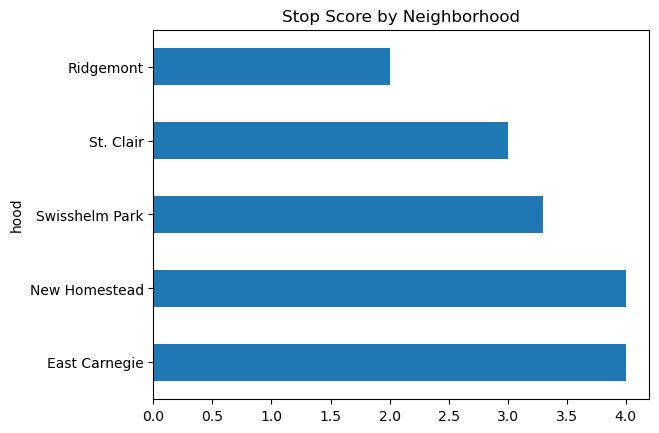

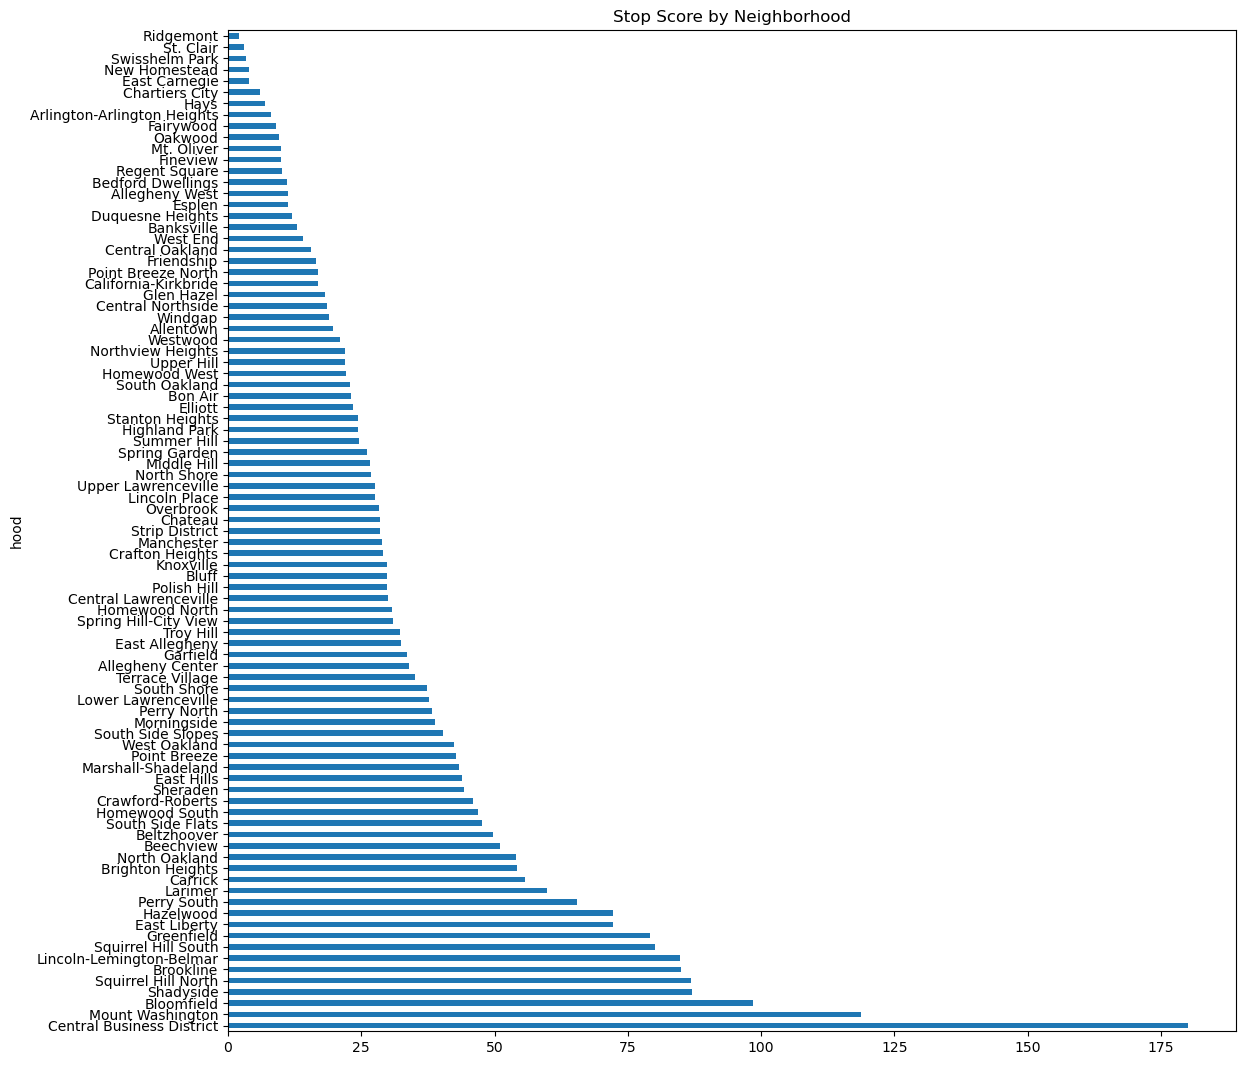

In [12]:
## main stop scoring

#count routes at each stop
stops['route_count'] = (
    stops['route_code'] #take route code cell
        .fillna('') #handle if cell empty (shouldn't be, but just in case)
        .str.count(',') + 1 #get number of routes (number of commas + 1)
)

#stop scoring
#bus stops get 1 + 0.1 for each additional bus route
#rail (T) stops get 3 + 3 for each additional T line (red/blue/silver)
stops['base'] = stops['mode'].map({'BUS': 1, 'RAIL': 3})
stops['additive'] = stops['mode'].map({'BUS': 0.1, 'RAIL': 3})

#final score - take base score, add additive score based on # of routes
stops['stop_score'] = (
    stops['base'] + 
    stops['additive'] * (stops['route_count'] - 1).clip(lower=0)
)

#combine by neighborhood
hood_scores = (
    stops.groupby('hood')['stop_score']
        .sum() #add up scores
        .reset_index() #fixes index (so it doesn't try treat hood as an int)
        .sort_values(by=['stop_score'], ascending=False) #sort by score
)

print(hood_scores.head(10))
print(hood_scores.tail(10))


#graph
hood_scores.head(5).plot(
    kind='barh', 
    x='hood', 
    y='stop_score',  
    title='Stop Score by Neighborhood',
    legend=False
)

hood_scores.tail(5).plot(
    kind='barh', 
    x='hood', 
    y='stop_score', 
    title='Stop Score by Neighborhood',
    legend=False
)

hood_scores.plot(
    kind='barh', 
    x='hood', 
    y='stop_score', 
    figsize=(13,13), 
    title='Stop Score by Neighborhood',
    legend=False
)

By this metric, the **Central Business District** is the best neighborhood, followed by **Mount Washington** and **Bloomfield**.

### Luke - Parks
First, let's initialize the dataset and filter it.

In [1]:
# import pandas and load the data
import pandas as pd
parks = pd.read_csv("parks.csv")

# Filter out non-park entries and isolate the important columns
parks = parks[parks.type == "Park"]
parks = parks[["name", "neighborhood"]]
parks

,name,neighborhood
0,Able Long Park,Beechview
1,Albert Turk Graham Park,Crawford-Roberts
2,Alcoa Park,North Shore
3,Allegheny Commons,Allegheny Center
4,Allegheny Landing Park,North Shore
...,...,...
203,Winters Park,South Side Slopes
204,Woods Run Park,Marshall-Shadeland
205,Young Field Park,Marshall-Shadeland
206,Zulema Park,Central Oakland


Now, we find our results:

<Axes: title={'center': 'Neighborhoods by Parks'}, ylabel='neighborhood'>

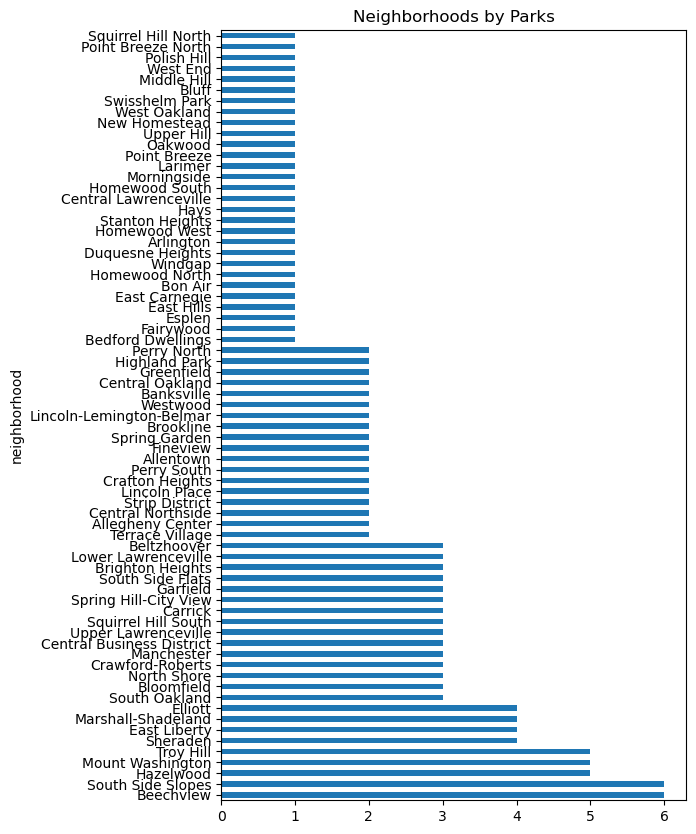

In [2]:
# Now, display the neighborhoods with the most parks
parks["neighborhood"].value_counts().plot(kind="barh", figsize=(6,10), title="Neighborhoods by Parks")

We can see that **South Side Slopes** and **Beechview** are tied for the best neighborhood with 6 parks each.

### Overall Analysis

We will build off of the existing neighborhood scores generated by the Transit Stop metric. Parks will add 20 points each, while condemned and dead-end buildings will subtract 1 point each.

We rewrote this cell to make it independent of running previous cells.

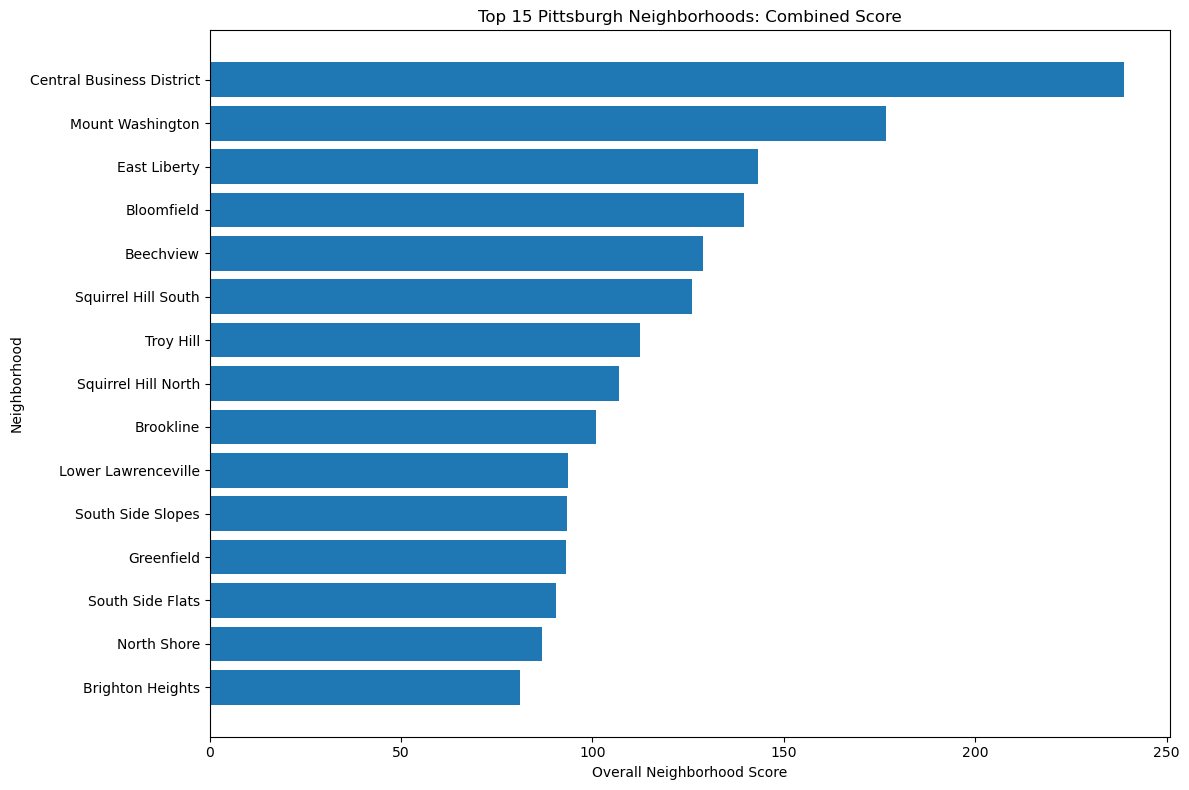

Best neighborhood: Central Business District
239.0


In [26]:
import pandas as pd
import matplotlib.pyplot as plt

#condemned/dead-end properties - from Mason
condemned = pd.read_csv('condemnedanddead-endproperties.csv')

#transit stops - from Michael
stops = pd.read_csv('transitstops.csv')

#parks - from Luke
parks = pd.read_csv('parks.csv')
parks = parks[parks['type'] == 'Park'][['name', 'neighborhood']]

#transit stops - from Michael
stops['route_count'] = stops['route_code'].fillna('').str.count(',') + 1
stops['base'] = stops['mode'].map({'BUS': 1,   'RAIL': 3})
stops['additive'] = stops['mode'].map({'BUS': 0.1, 'RAIL': 3})
stops['stop_score'] = stops['base'] + stops['additive'] * (stops['route_count'] - 1).clip(lower=0)

transit_scores = (
    stops.groupby('hood')['stop_score']
    .sum()
    .reset_index()
    .rename(columns={'hood': 'neighborhood', 'stop_score': 'transit_score'})
)


#scoring neighborhoods by parks amount
parks_scores = (
    parks.groupby('neighborhood')
    .size()
    .reset_index(name='park_count')
)
parks_scores['parks_score'] = parks_scores['park_count'] * 20


#deducting 1 point per condemned property
condemned_counts = (
    condemned.groupby('neighborhood')
    .size()
    .reset_index(name='condemned_count')
)
condemned_counts['condemned_penalty'] = -1 * condemned_counts['condemned_count']


#merging all the scores into one final master score

#start from the existing transit scores that Michael made
df = transit_scores.copy()
df = df.merge(parks_scores[['neighborhood', 'parks_score']], on='neighborhood', how='outer')
df = df.merge(condemned_counts[['neighborhood', 'condemned_penalty']], on='neighborhood', how='outer')

#fill missing values with 0
df[['transit_score', 'parks_score', 'condemned_penalty']] = (
    df[['transit_score', 'parks_score', 'condemned_penalty']].fillna(0)
)

df['final_score'] = df['transit_score'] + df['parks_score'] + df['condemned_penalty']
df = df.sort_values('final_score', ascending=False).reset_index(drop=True)

#show the top 15 neighborhoods


top15 = df.head(15)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top15['neighborhood'], top15['final_score'])

ax.set_xlabel('Overall Neighborhood Score')
ax.set_ylabel('Neighborhood')
ax.set_title('Top 15 Pittsburgh Neighborhoods: Combined Score')
ax.invert_yaxis()  # best at the top
plt.tight_layout()
plt.show()

#show results
winnerRow = df.iloc[0]
print("Best neighborhood: "  + winnerRow['neighborhood'])
print(winnerRow['final_score'])